# FYP: #SAT Solver Portfolio Selector

**Author:** Ewan  
**Objective:** Analysis of SAT instance features and counter performance to build a lightweight portfolio selector. 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for readability
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

TIMEOUT_LIMIT = 5000

## 1. Data Loading and Merging
There is two datasets: 
* `MC_performance_final.csv`: Contains time, solutions, and memory for 8 counter variants.
* `instances_features_final.csv`: Contains 30+ SATzilla-style features for each instance.

These are merged on the `file_name` column to create the dataset.

In [7]:
perf_df = pd.read_csv('MC_performances_final.csv')
feat_df = pd.read_csv('instances_features_final.csv')

print(f"Performance data shape: {perf_df.shape}")
print(f"Feature data shape: {feat_df.shape}")

df = pd.merge(feat_df, perf_df, on='file_name', how='inner')
print(f"Merged data shape: {df.shape}")

df.head()

Performance data shape: (2023, 25)
Feature data shape: (2023, 75)
Merged data shape: (2023, 99)


,c,v,clauses_vars_ratio,vars_clauses_ratio,vcg_var_mean,vcg_var_coeff,vcg_var_min,vcg_var_max,vcg_var_entropy,vcg_clause_mean,...,memory_ganak,time_ganak_no,solutions_ganak_no,memory_ganak_no,time_approxmc,solutions_approxmc,memory_approxmc,time_approxmc_no,solutions_approxmc_no,memory_approxmc_no
0,315.0,120.0,2.625000,0.380952,0.021032,0.484848,0.00000,0.057143,1.875980,0.021032,...,-1.0,0.006962,7.11751,-1.0,0.00,7.117510,6.625000,0.01,7.117510,6.589844
1,17198.0,6152.0,2.795514,0.357716,0.000521,3.252365,0.00000,0.029771,1.783566,0.000521,...,NaN,100000.000000,NaN,NaN,85.65,316.389259,1194.027344,23.86,316.395889,337.511719
2,500.0,200.0,2.500000,0.400000,0.013000,0.483821,0.00000,0.040000,1.719154,0.013000,...,NaN,100000.000000,NaN,NaN,0.02,30.103000,NaN,0.01,30.103000,NaN
3,369.0,140.0,2.635714,0.379404,0.017983,0.444577,0.00542,0.054201,1.804346,0.017983,...,-1.0,0.022873,10.58294,-1.0,0.03,10.574968,6.957031,0.01,10.562379,6.644531
4,368.0,140.0,2.628571,0.380435,0.018012,0.455573,0.00000,0.054348,1.825238,0.018012,...,-1.0,1.064320,14.30663,-1.0,0.05,14.333456,7.597656,0.02,14.245320,6.640625


## 2. Defining Target Variables

* **Is UNSAT:** Are the solutions equal to 0?
* **Is Hard:** Did all solvers hit the timeout limit?
* **Best Counter:** Which solver had the lowest time (excluding those that timed out)?

In [8]:
df = df.copy()
solvers = ['d4', 'gpmc', 'addmc', 'sharpsat', 'ganak', 'ganak_no', 'approxmc', 'approxmc_no']
time_cols = [f"time_{s}" for s in solvers]
solution_cols = [f"solutions_{s}" for s in solvers]

# TARGET 1: SAT vs UNSAT
df['is_unsat'] = df[solution_cols].apply(lambda x: 1 if 0 in x.values else 0, axis=1)

# TARGET 2: Hardness (Timeout)
df['min_time'] = df[time_cols].min(axis=1)
df['is_hard'] = (df['min_time'] >= TIMEOUT_LIMIT).astype(int)

# TARGET 3: Best Counter (Consensus Selector)
def find_fastest_correct_solver(row):
    """
    Finds the fastest solver that agrees with at least 2 other solvers 
    (i.e., >= 3 solvers report the same solution).
    """
    sols = row[solution_cols].dropna()
    if len(sols) < 3:
        return np.nan
        
    sols_rounded = sols.astype(float).round(5)
    counts = sols_rounded.value_counts()
    
    if counts.empty or counts.iloc[0] < 3:
        return np.nan
        
    consensus_val = counts.index[0]
    best_time = float('inf')
    best_solver = np.nan
    
    for solver in solvers:
        sol_val = row[f'solutions_{solver}']
        time_val = row[f'time_{solver}']
        
        if pd.notna(sol_val) and np.round(float(sol_val), 5) == consensus_val:
            if time_val < TIMEOUT_LIMIT and time_val < best_time:
                best_time = time_val
                best_solver = solver
                
    return best_solver

df['best_solver'] = df.apply(find_fastest_correct_solver, axis=1)

print("Total Instances:", len(df))
print(f"Instances with a valid consensus winner: {df['best_solver'].notna().sum()}")
print("\nBest Solver Distribution (Consensus Winners):")
print(df['best_solver'].value_counts())

Total Instances: 2023
Instances with a valid consensus winner: 1401

Best Solver Distribution (Consensus Winners):
best_solver
gpmc           804
d4             153
approxmc_no     97
ganak_no        91
ganak           76
approxmc        74
sharpsat        55
addmc           51
Name: count, dtype: int64


C:\Users\ewanf\AppData\Local\Temp\ipykernel_35220\1629447268.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


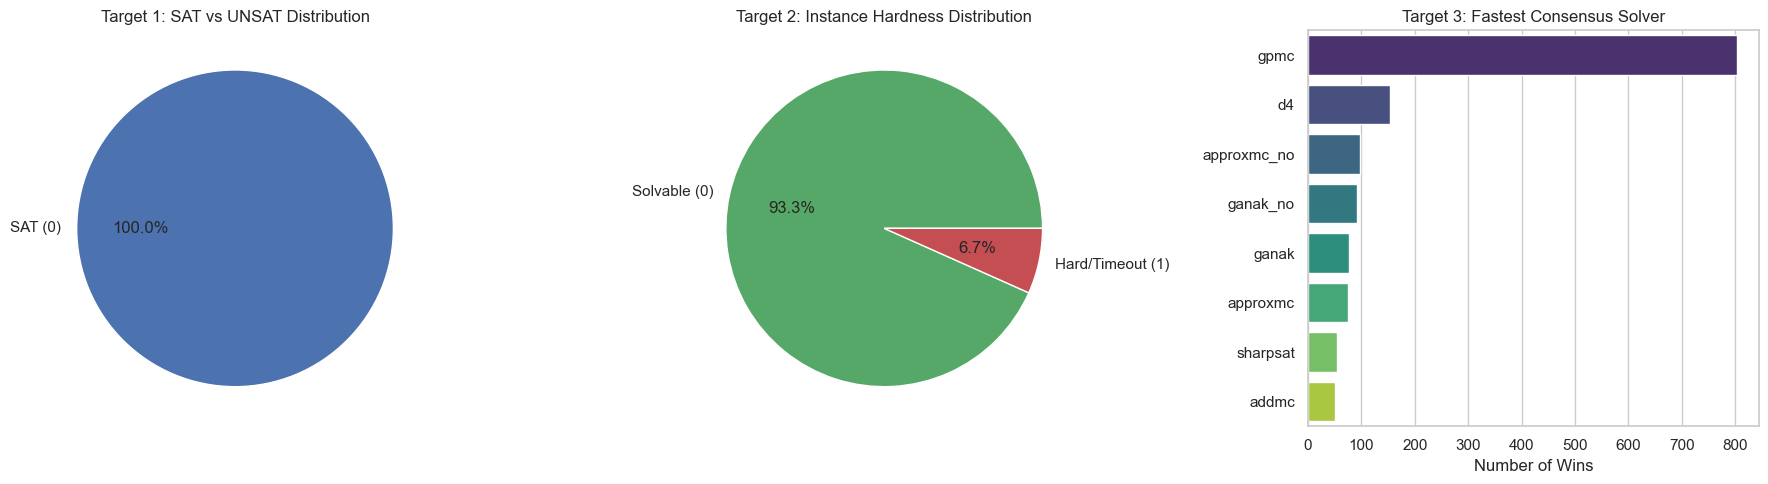

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: SAT vs UNSAT
unsat_counts = df['is_unsat'].value_counts()
unsat_map = {0: 'SAT (0)', 1: 'UNSAT (1)'}
# Dynamically grab the labels based on what's actually in the data
unsat_labels = [unsat_map[val] for val in unsat_counts.index]

axes[0].pie(unsat_counts, labels=unsat_labels, autopct='%1.1f%%', 
            colors=['#4C72B0', '#DD8452'][:len(unsat_counts)])
axes[0].set_title('Target 1: SAT vs UNSAT Distribution')

# Plot 2: Hardness
hard_counts = df['is_hard'].value_counts()
hard_map = {0: 'Solvable (0)', 1: 'Hard/Timeout (1)'}
hard_labels = [hard_map[val] for val in hard_counts.index]

axes[1].pie(hard_counts, labels=hard_labels, autopct='%1.1f%%', 
            colors=['#55A868', '#C44E52'][:len(hard_counts)])
axes[1].set_title('Target 2: Instance Hardness Distribution')

# Plot 3: Best Solver (Consensus Winners)
df_solved = df.dropna(subset=['best_solver'])
sns.countplot(
    data=df_solved, 
    y='best_solver', 
    ax=axes[2], 
    order=df_solved['best_solver'].value_counts().index, 
    palette='viridis'
)
axes[2].set_title('Target 3: Fastest Consensus Solver')
axes[2].set_xlabel('Number of Wins')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Data Preprocessing for ML
To build the Counter Selector, only instances that were solvable and achieved consensus (`df_solved`) are used. 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

exclude_cols = list(perf_df.columns) + ['is_unsat', 'is_hard', 'min_time', 'best_solver', 'satzilla_base_t', 'satzilla_probe_t']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df_solved[feature_cols].copy()
y = df_solved['best_solver'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Features shape: (1401, 72)
Target shape: (1401,)
Training set size: 1120
Test set size: 281


## 6. Portfolio Evaluation Metrics
Accuracy doesn't capture the true goal of an algorithm portfolio. Below are more specific measures

* **PAR-2 Score:** Time taken to solve, but heavily penalized if the solver fails, times out, or returns an incorrect count.
* **Speedup:** How much faster the ML Portfolio is compared to the Single Best Solver (SBS).
* **Oracle (VBS):** The theoretical maximum performance if we always chose the perfect solver.

In [11]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def evaluate_portfolio(y_true, y_pred, test_indices, df, timeout=5000, sbs_name='gpmc'):
    """
    Evaluates the predicted portfolio against the Single Best Solver (SBS) 
    and Virtual Best Solver (Oracle). Prints ML metrics and PAR-2 scores.
    """
    # 1. Standard ML Metrics
    print("==================================================")
    print("               ML CLASSIFICATION METRICS          ")
    print("==================================================")
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, 
        xticks_rotation=45, 
        cmap='Blues', 
        ax=ax
    )
    plt.title("Portfolio Model Confusion Matrix")
    plt.show()

    # 2. PAR-2 and Speedup Metrics
    portfolio_par2, sbs_par2, oracle_par2 = 0, 0, 0
    portfolio_solved, sbs_solved, oracle_solved = 0, 0, 0
    
    for i, idx in enumerate(test_indices):
        pred_solver = y_pred[i]
        true_solver = df.loc[idx, 'best_solver'] 
        
        oracle_time = df.loc[idx, f'time_{true_solver}']
        oracle_par2 += oracle_time
        oracle_solved += 1 
        
        def score_solver(solver_name):
            time_taken = df.loc[idx, f'time_{solver_name}']
            
            if time_taken >= timeout or pd.isna(time_taken):
                return timeout * 2, False
                
            pred_sol = np.round(float(df.loc[idx, f'solutions_{solver_name}']), 5)
            true_sol = np.round(float(df.loc[idx, f'solutions_{true_solver}']), 5)
            
            if pd.isna(pred_sol) or pred_sol != true_sol:
                return timeout * 2, False 
            
            return time_taken, True

        p_score, p_solved = score_solver(pred_solver)
        portfolio_par2 += p_score
        portfolio_solved += int(p_solved)
        
        s_score, s_solved = score_solver(sbs_name)
        sbs_par2 += s_score
        sbs_solved += int(s_solved)

    print("==================================================")
    print("               PORTFOLIO PAR-2 METRICS            ")
    print("==================================================")
    total_instances = len(test_indices)
    print(f"Exact Counts Obtained:")
    print(f"  Oracle (VBS):  {oracle_solved}/{total_instances}")
    print(f"  SBS ({sbs_name}):   {sbs_solved}/{total_instances}")
    print(f"  ML Portfolio:  {portfolio_solved}/{total_instances}")
    
    print(f"\nTotal PAR-2 Score (Lower is better):")
    print(f"  Oracle (VBS):  {oracle_par2:,.2f}")
    print(f"  SBS ({sbs_name}):   {sbs_par2:,.2f}")
    print(f"  ML Portfolio:  {portfolio_par2:,.2f}")
    
    if portfolio_par2 < sbs_par2:
        speedup = sbs_par2 / portfolio_par2
        print(f"\n Speedup: Portfolio is {speedup:.2f}x better than guessing {sbs_name}!")
    else:
        loss = portfolio_par2 / sbs_par2
        print(f"\n Slowdown: Portfolio is {loss:.2f}x worse than just guessing {sbs_name}.")
        
    return portfolio_par2, sbs_par2

## 8. Baseline Model: k-Nearest-Neighbours
A simple k-NN classifier trained as the baseline.

               ML CLASSIFICATION METRICS          
Accuracy: 59.07%

Classification Report:
              precision    recall  f1-score   support

       addmc       0.50      0.80      0.62        10
    approxmc       0.00      0.00      0.00        15
 approxmc_no       0.38      0.25      0.30        20
          d4       0.39      0.35      0.37        31
       ganak       0.28      0.33      0.30        15
    ganak_no       0.15      0.11      0.13        18
        gpmc       0.74      0.83      0.78       161
    sharpsat       0.14      0.09      0.11        11

    accuracy                           0.59       281
   macro avg       0.32      0.35      0.33       281
weighted avg       0.54      0.59      0.56       281



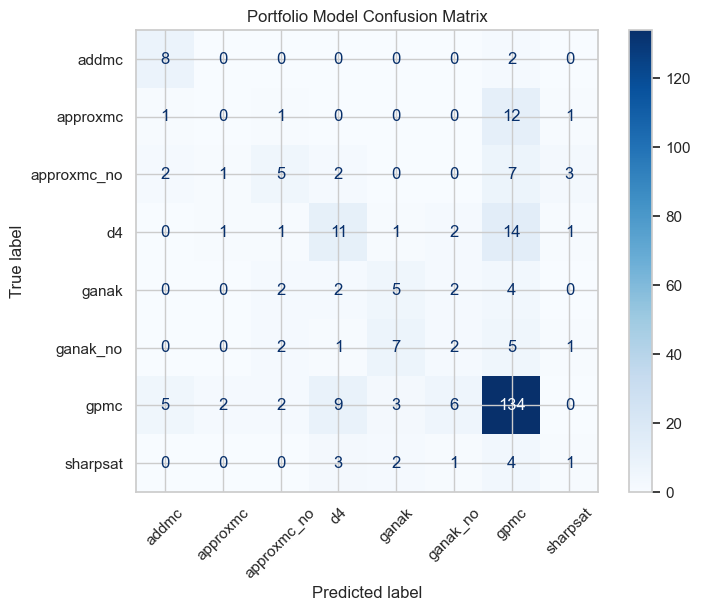

               PORTFOLIO PAR-2 METRICS            
Exact Counts Obtained:
  Oracle (VBS):  281/281
  SBS (gpmc):   281/281
  ML Portfolio:  271/281

Total PAR-2 Score (Lower is better):
  Oracle (VBS):  1,070.68
  SBS (gpmc):   3,898.60
  ML Portfolio:  104,784.19

 Slowdown: Portfolio is 26.88x worse than just guessing gpmc.


(np.float64(104784.19283999983), np.float64(3898.5999999999995))

In [12]:
from sklearn.neighbors import KNeighborsClassifier



knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

evaluate_portfolio(
    y_pred=y_pred_knn, 
    y_true=y_test,
    test_indices=y_test.index, 
    df=df_solved, 
    timeout=TIMEOUT_LIMIT, 
    sbs_name='gpmc'
)

## 8. Model 2: Decision Tree Ensemble (Random Forest)
k-NN struggled because it maps data linearly and gets easily overwhelmed by majority classes. To combat the massive amount of `gpmc` wins `class_weight='balanced'` is used. This penalizes the model heavily if it gets the minority classes wrong, forcing it to look for those structural feature rules.

               ML CLASSIFICATION METRICS          
Accuracy: 66.90%

Classification Report:
              precision    recall  f1-score   support

       addmc       0.75      0.90      0.82        10
    approxmc       0.25      0.07      0.11        15
 approxmc_no       0.62      0.25      0.36        20
          d4       0.58      0.48      0.53        31
       ganak       0.46      0.40      0.43        15
    ganak_no       0.55      0.33      0.41        18
        gpmc       0.72      0.89      0.79       161
    sharpsat       0.38      0.27      0.32        11

    accuracy                           0.67       281
   macro avg       0.54      0.45      0.47       281
weighted avg       0.63      0.67      0.64       281



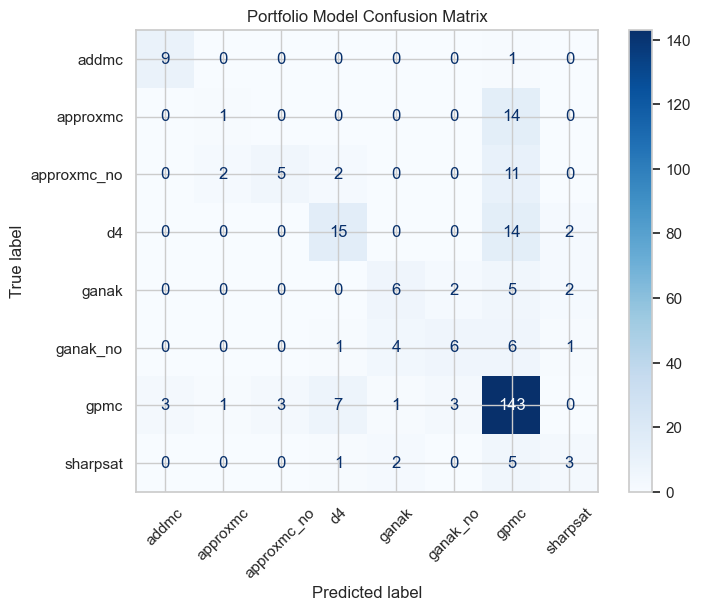

               PORTFOLIO PAR-2 METRICS            
Exact Counts Obtained:
  Oracle (VBS):  281/281
  SBS (gpmc):   281/281
  ML Portfolio:  278/281

Total PAR-2 Score (Lower is better):
  Oracle (VBS):  1,070.68
  SBS (gpmc):   3,898.60
  ML Portfolio:  33,416.35

 Slowdown: Portfolio is 8.57x worse than just guessing gpmc.


(np.float64(33416.35071199997), np.float64(3898.5999999999995))

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate_portfolio(
    y_true=y_test,
    y_pred=y_pred_rf, 
    test_indices=y_test.index, 
    df=df_solved, 
    timeout=TIMEOUT_LIMIT, 
    sbs_name='gpmc'
)

## 9. Feature Importances
To understand how Random Forest makes decisions—and to help design rule-based tie-breakers—we need to see which features the model values the most.

C:\Users\ewanf\AppData\Local\Temp\ipykernel_35220\1186316022.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


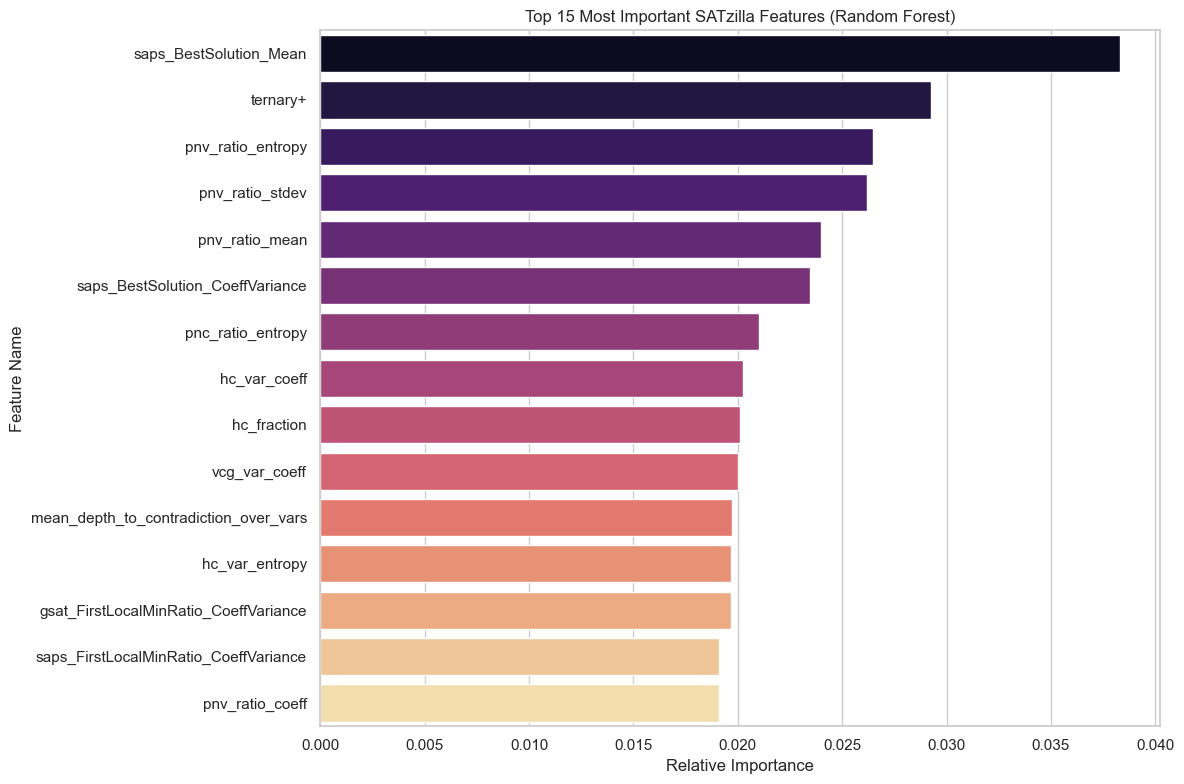

In [14]:
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importance_df.head(15), 
    x='Importance', 
    y='Feature', 
    palette='magma'
)
plt.title('Top 15 Most Important SATzilla Features (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## 10. Probabilistic Rule-Based Tie-Breaker
This tie-breaker rule overrides a gpmc prediction and switches it to approxmc only if the model's confidence is below 0.55, the clause count exceeds 1000, and the probability for approxmc is at least 0.1.

               ML CLASSIFICATION METRICS          
Accuracy: 66.19%

Classification Report:
              precision    recall  f1-score   support

       addmc       0.75      0.90      0.82        10
    approxmc       0.17      0.07      0.10        15
 approxmc_no       0.62      0.25      0.36        20
          d4       0.58      0.48      0.53        31
       ganak       0.46      0.40      0.43        15
    ganak_no       0.55      0.33      0.41        18
        gpmc       0.72      0.88      0.79       161
    sharpsat       0.38      0.27      0.32        11

    accuracy                           0.66       281
   macro avg       0.53      0.45      0.47       281
weighted avg       0.63      0.66      0.63       281



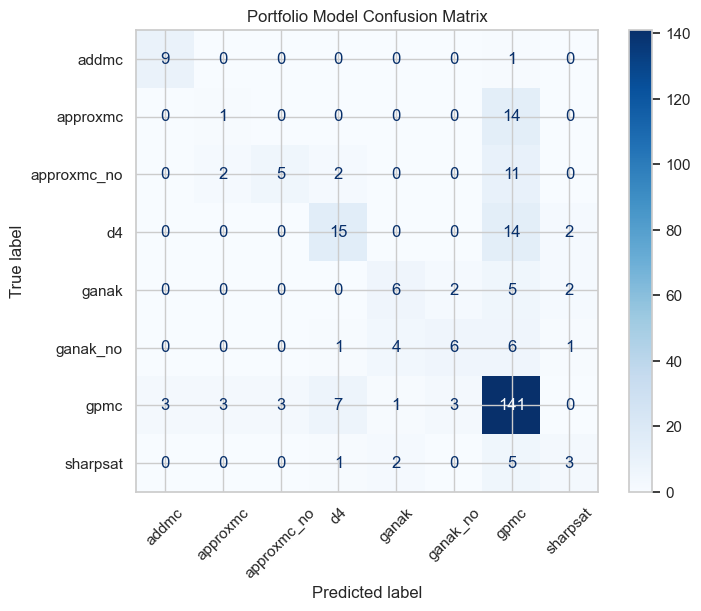

               PORTFOLIO PAR-2 METRICS            
Exact Counts Obtained:
  Oracle (VBS):  281/281
  SBS (gpmc):   281/281
  ML Portfolio:  276/281

Total PAR-2 Score (Lower is better):
  Oracle (VBS):  1,070.68
  SBS (gpmc):   3,898.60
  ML Portfolio:  53,415.87

 Slowdown: Portfolio is 13.70x worse than just guessing gpmc.


(np.float64(53415.87071200001), np.float64(3898.5999999999995))

In [16]:
def predict_with_tiebreakers(model, X_test_scaled, test_indices, df_raw, clause_threshold=1000, confidence_threshold=0.5):
    """
    Uses model probabilities to apply rules ONLY when the model is uncertain.
    """
    proba = model.predict_proba(X_test_scaled)
    classes = model.classes_
    
    hybrid_preds = []
    
    for i, idx in enumerate(test_indices):
        best_idx = np.argmax(proba[i])
        pred = classes[best_idx]
        confidence = proba[i][best_idx]
        
        c_val = df_raw.loc[idx, 'c']
        
        # --- THE TIE-BREAKER RULE ---
        if pred == 'gpmc' and confidence < confidence_threshold and c_val > clause_threshold:
            approxmc_idx = np.where(classes == 'approxmc')[0][0]
            if proba[i][approxmc_idx] > 0.1:
                pred = 'approxmc'
            
        hybrid_preds.append(pred)
        
    return np.array(hybrid_preds)

y_pred_prob_hybrid = predict_with_tiebreakers(
    model=rf_model, 
    X_test_scaled=X_test, 
    test_indices=y_test.index, 
    df_raw=df_solved,
    clause_threshold=1000, 
    confidence_threshold=0.55 
)

evaluate_portfolio(
    y_true=y_test,
    y_pred=y_pred_prob_hybrid, 
    test_indices=y_test.index, 
    df=df_solved, 
    timeout=TIMEOUT_LIMIT, 
    sbs_name='gpmc'
)

## 11. Model Testing
Since hardcoded rules backfired, a different approach is tried. A suite of different algorithms is tested out-of-the-box to see which architecture naturally handles the complexities of SATzilla features best.

Tested:
1. **Linear:** Logistic Regression
2. **Support Vector:** SVM
3. **Tree Ensembles:** Random Forest, Extra Trees
4. **Gradient Boosters:** XGBoost, LightGBM, CatBoost
5. **Neural Network:** Multi-Layer Perceptron (MLP)

In [18]:
import time
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "SVM (RBF Kernel)": SVC(class_weight='balanced', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, scale_pos_weight=1, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=100, auto_class_weights='Balanced', random_state=42, verbose=0),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

def get_stats(y_pred_str, test_indices, df_raw, timeout=5000):
    portfolio_par2 = 0
    portfolio_solved = 0
    for i, idx in enumerate(test_indices):
        pred_solver = y_pred_str[i]
        true_solver = df_raw.loc[idx, 'best_solver']
        
        time_taken = df_raw.loc[idx, f'time_{pred_solver}']
        
        if time_taken >= timeout or pd.isna(time_taken):
            portfolio_par2 += timeout * 2
            continue
            
        pred_sol = np.round(float(df_raw.loc[idx, f'solutions_{pred_solver}']), 5)
        true_sol = np.round(float(df_raw.loc[idx, f'solutions_{true_solver}']), 5)
        
        if pd.isna(pred_sol) or pred_sol != true_sol:
            portfolio_par2 += timeout * 2
        else:
            portfolio_par2 += time_taken
            portfolio_solved += 1
            
    return portfolio_par2, portfolio_solved

results = []

for name, model in models.items():
    start_time = time.time()
    
    model.fit(X_train_enc, y_train_enc)
    y_pred_enc = model.predict(X_test_enc)

    y_pred_str = le.inverse_transform(y_pred_enc)
    
    y_test_str = le.inverse_transform(y_test_enc)
    acc = np.mean(y_pred_str == y_test_str)
    
    par2, solved = get_stats(y_pred_str, y_test.index, df_solved, TIMEOUT_LIMIT)
    train_time = time.time() - start_time
    
    results.append({
        "Model": name,
        "Accuracy": f"{acc*100:.2f}%",
        "Exact Counts": f"{solved}/281",
        "PAR-2 Score": par2,
        "Train Time (s)": f"{train_time:.2f}"
    })
    print(f"✅ {name} finished in {train_time:.2f}s (PAR-2: {par2:,.2f})")

leaderboard = pd.DataFrame(results).sort_values(by="PAR-2 Score")
print("\n LEADERBOARD")
print("-" * 65)
display(leaderboard)

✅ Logistic Regression finished in 0.10s (PAR-2: 226,000.43)
✅ SVM (RBF Kernel) finished in 0.47s (PAR-2: 374,965.85)
✅ Random Forest finished in 0.39s (PAR-2: 33,416.35)
✅ Extra Trees finished in 0.22s (PAR-2: 73,377.58)


c:\Users\ewanf\Documents\college\FYP\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:27:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost finished in 0.91s (PAR-2: 93,242.39)


c:\Users\ewanf\Documents\college\FYP\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM finished in 0.84s (PAR-2: 93,333.07)


c:\Users\ewanf\Documents\college\FYP\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:161: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


✅ CatBoost finished in 2.52s (PAR-2: 184,980.84)
✅ Neural Network (MLP) finished in 3.09s (PAR-2: 135,577.24)

 LEADERBOARD
-----------------------------------------------------------------


,Model,Accuracy,Exact Counts,PAR-2 Score,Train Time (s)
2,Random Forest,66.90%,278/281,33416.350712,0.39
3,Extra Trees,65.12%,274/281,73377.583849,0.22
4,XGBoost,64.77%,272/281,93242.393222,0.91
5,LightGBM,63.35%,272/281,93333.066902,0.84
7,Neural Network (MLP),59.07%,268/281,135577.236981,3.09
6,CatBoost,55.52%,263/281,184980.840091,2.52
0,Logistic Regression,45.91%,259/281,226000.425038,0.10
1,SVM (RBF Kernel),40.21%,244/281,374965.852407,0.47


## 12. Model 2: The Hardness Predictor
Before the selector tool picks a specific counter, it needs to predict if the instance is simply too hard to solve within the timeout limit. This is a binary classification problem predicting the `is_hard` target (1 = All solvers timeout, 0 = At least one solver finishes).


           HARDNESS PREDICTOR METRICS             
Accuracy:  98.77%
Precision: 95.83%
Recall:    85.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       378
           1       0.96      0.85      0.90        27

    accuracy                           0.99       405
   macro avg       0.97      0.92      0.95       405
weighted avg       0.99      0.99      0.99       405



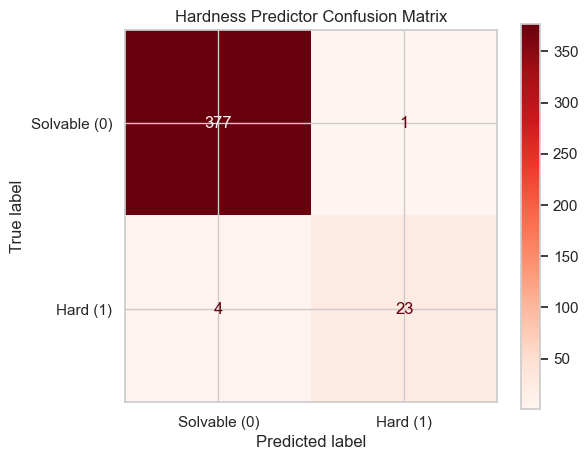

In [20]:
from sklearn.metrics import precision_score, recall_score

X_all = df[feature_cols].copy()
y_hard = df['is_hard'].copy()

X_all_imputed = imputer.fit_transform(X_all)
X_all_scaled = scaler.fit_transform(X_all_imputed)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_all_scaled, y_hard, test_size=0.2, random_state=42, stratify=y_hard
)

rf_hardness = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_hardness.fit(X_train_h, y_train_h)

y_pred_h = rf_hardness.predict(X_test_h)

print("==================================================")
print("           HARDNESS PREDICTOR METRICS             ")
print("==================================================")
print(f"Accuracy:  {accuracy_score(y_test_h, y_pred_h) * 100:.2f}%")
print(f"Precision: {precision_score(y_test_h, y_pred_h) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test_h, y_pred_h) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_h, y_pred_h))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_h, y_pred_h, 
    display_labels=['Solvable (0)', 'Hard (1)'],
    cmap='Reds', 
    ax=ax
)
plt.title("Hardness Predictor Confusion Matrix")
plt.show()

## 13. Full Portfolio Pipeline Evaluation
Now the two models are combined.

1. Pass the instance features to the `rf_hardness` model.
2. If it predicts `1` (Hard), we do not run any solver.
3. If it predicts `0` (Solvable), we pass the features to the `rf_model` to pick the best counter.
4. We evaluate this entire system's PAR-2 score and exact counts against the Single Best Solver (GPMC).

In [22]:
def evaluate_full_pipeline(X_features, test_indices, df_raw, hardness_model, selector_model, timeout=5000, sbs_name='gpmc'):
    portfolio_par2 = 0
    sbs_par2 = 0
    oracle_par2 = 0
    
    portfolio_solved = 0
    sbs_solved = 0
    oracle_solved = 0
    
    time_saved_by_bouncer = 0
    
    print("Running Full Pipeline Simulation...")
    
    for i, idx in enumerate(test_indices):
        true_solver = df_raw.loc[idx, 'best_solver']
        if df_raw.loc[idx, 'is_hard'] == 1 or pd.isna(true_solver):
            oracle_par2 += timeout * 2
            true_sol = np.nan 
        else:
            oracle_par2 += df_raw.loc[idx, f'time_{true_solver}']
            oracle_solved += 1
            true_sol = np.round(float(df_raw.loc[idx, f'solutions_{true_solver}']), 5)
            
        sbs_time = df_raw.loc[idx, f'time_{sbs_name}']
        sbs_sol = np.round(float(df_raw.loc[idx, f'solutions_{sbs_name}']), 5)
        
        if pd.isna(sbs_time) or sbs_time >= timeout or pd.isna(true_sol) or sbs_sol != true_sol:
            sbs_par2 += timeout * 2
        else:
            sbs_par2 += sbs_time
            sbs_solved += 1

        is_hard_pred = hardness_model.predict(X_features[i].reshape(1, -1))[0]
        
        if is_hard_pred == 1:
            portfolio_par2 += timeout * 2
            if df_raw.loc[idx, 'is_hard'] == 1:
                time_saved_by_bouncer += timeout
            continue 
            
        pred_solver = selector_model.predict(X_features[i].reshape(1, -1))[0]
        
        p_time = df_raw.loc[idx, f'time_{pred_solver}']
        p_sol = np.round(float(df_raw.loc[idx, f'solutions_{pred_solver}']), 5)
        
        if pd.isna(p_time) or p_time >= timeout or pd.isna(true_sol) or p_sol != true_sol:
            portfolio_par2 += timeout * 2
        else:
            portfolio_par2 += p_time
            portfolio_solved += 1

    total_instances = len(test_indices)
    print("==================================================")
    print("          FINAL PIPELINE EVALUATION               ")
    print("==================================================")
    print(f"Total Instances Tested: {total_instances}")
    print(f"Wall-Clock Time Saved by Hardness Bouncer: {time_saved_by_bouncer:,.0f} seconds\n")
    
    print(f"Exact Counts Obtained:")
    print(f"  Oracle (Theoretical Max): {oracle_solved}/{total_instances}")
    print(f"  SBS ({sbs_name}):            {sbs_solved}/{total_instances}")
    print(f"  ML Portfolio:        {portfolio_solved}/{total_instances}")
    
    print(f"\nTotal PAR-2 Score:")
    print(f"  Oracle (VBS):  {oracle_par2:,.2f}")
    print(f"  SBS ({sbs_name}):   {sbs_par2:,.2f}")
    print(f"  ML Portfolio:  {portfolio_par2:,.2f}")

# Run the evaluation
evaluate_full_pipeline(
    X_features=X_test_h, 
    test_indices=y_test_h.index, 
    df_raw=df, 
    hardness_model=rf_hardness, 
    selector_model=rf_model,
    timeout=TIMEOUT_LIMIT,
    sbs_name='gpmc'
)

Running Full Pipeline Simulation...
          FINAL PIPELINE EVALUATION               
Total Instances Tested: 405
Wall-Clock Time Saved by Hardness Bouncer: 115,000 seconds

Exact Counts Obtained:
  Oracle (Theoretical Max): 276/405
  SBS (gpmc):            272/405
  ML Portfolio:        270/405

Total PAR-2 Score:
  Oracle (VBS):  1,290,237.95
  SBS (gpmc):   1,331,159.61
  ML Portfolio:  1,355,456.47


## 14. 5-Fold Cross-Validation
The dataset is relatively small. To ensure PAR-2 scores aren't the result of a "lucky" or "unlucky" train/test split,  5-Fold Stratified Cross-Validation is used.

In [23]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_portfolio_par2, cv_sbs_par2, cv_oracle_par2 = 0, 0, 0
cv_portfolio_solved, cv_sbs_solved, cv_oracle_solved = 0, 0, 0
cv_time_saved = 0
timeout = TIMEOUT_LIMIT
sbs_name = 'gpmc'

print("Starting 5-Fold Cross-Validation (This will train 10 models total)...\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_scaled, y_hard)):
    print(f"--- Processing Fold {fold + 1}/5 ---")
    
    X_train_fold, X_test_fold = X_all_scaled[train_idx], X_all_scaled[test_idx]
    y_hard_train_fold = y_hard.iloc[train_idx]
    
    train_df_fold = df.iloc[train_idx]
    valid_selector_mask = train_df_fold['best_solver'].notna().values
    
    X_train_selector = X_train_fold[valid_selector_mask]
    y_train_selector = train_df_fold['best_solver'].dropna().values
    
    rf_bouncer = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_bouncer.fit(X_train_fold, y_hard_train_fold)
    
    rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_selector.fit(X_train_selector, y_train_selector)
    
    test_actual_indices = df.iloc[test_idx].index 
    
    for i, idx in enumerate(test_actual_indices):
        true_solver = df.loc[idx, 'best_solver']
        
        if df.loc[idx, 'is_hard'] == 1 or pd.isna(true_solver):
            cv_oracle_par2 += timeout * 2
            true_sol = np.nan
        else:
            cv_oracle_par2 += df.loc[idx, f'time_{true_solver}']
            cv_oracle_solved += 1
            true_sol = np.round(float(df.loc[idx, f'solutions_{true_solver}']), 5)
            
        sbs_time = df.loc[idx, f'time_{sbs_name}']
        sbs_sol = np.round(float(df.loc[idx, f'solutions_{sbs_name}']), 5)
        if pd.isna(sbs_time) or sbs_time >= timeout or pd.isna(true_sol) or sbs_sol != true_sol:
            cv_sbs_par2 += timeout * 2
        else:
            cv_sbs_par2 += sbs_time
            cv_sbs_solved += 1

        is_hard_pred = rf_bouncer.predict(X_test_fold[i].reshape(1, -1))[0]
        if is_hard_pred == 1:
            cv_portfolio_par2 += timeout * 2
            if df.loc[idx, 'is_hard'] == 1:
                cv_time_saved += timeout
            continue
            
        pred_solver = rf_selector.predict(X_test_fold[i].reshape(1, -1))[0]
        p_time = df.loc[idx, f'time_{pred_solver}']
        p_sol = np.round(float(df.loc[idx, f'solutions_{pred_solver}']), 5)
        
        if pd.isna(p_time) or p_time >= timeout or pd.isna(true_sol) or p_sol != true_sol:
            cv_portfolio_par2 += timeout * 2
        else:
            cv_portfolio_par2 += p_time
            cv_portfolio_solved += 1

total_instances = len(df)
print("\n==================================================")
print("     5-FOLD CROSS-VALIDATION FINAL REPORT         ")
print("==================================================")
print(f"Total Instances Evaluated: {total_instances}")
print(f"Total Wall-Clock Time Saved: {cv_time_saved:,.0f} seconds\n")

print(f"Total Exact Counts Obtained:")
print(f"  Oracle (Theoretical Max): {cv_oracle_solved}/{total_instances}")
print(f"  SBS ({sbs_name}):            {cv_sbs_solved}/{total_instances}")
print(f"  Your ML Portfolio:        {cv_portfolio_solved}/{total_instances}")

print(f"\nTotal PAR-2 Score (Lower is better):")
print(f"  Oracle (VBS):  {cv_oracle_par2:,.2f}")
print(f"  SBS ({sbs_name}):   {cv_sbs_par2:,.2f}")
print(f"  ML Portfolio:  {cv_portfolio_par2:,.2f}")

Starting 5-Fold Cross-Validation (This will train 10 models total)...

--- Processing Fold 1/5 ---
--- Processing Fold 2/5 ---
--- Processing Fold 3/5 ---
--- Processing Fold 4/5 ---
--- Processing Fold 5/5 ---

     5-FOLD CROSS-VALIDATION FINAL REPORT         
Total Instances Evaluated: 2023
Total Wall-Clock Time Saved: 520,000 seconds

Total Exact Counts Obtained:
  Oracle (Theoretical Max): 1401/2023
  SBS (gpmc):            1378/2023
  Your ML Portfolio:        1387/2023

Total PAR-2 Score (Lower is better):
  Oracle (VBS):  6,222,786.52
  SBS (gpmc):   6,462,886.69
  ML Portfolio:  6,375,679.77


## 15. Feature Selection for a Lightweight Tool
A truly lightweight portfolio selector shouldn't spend excessive time computing 75+ features before making a decision. To start RFE is used to determine the optimal number of features before accuracy drops.


--- Starting RFE for BOUNCER ---
Features: 70 | Score: 0.8444
Features: 60 | Score: 0.8451
Features: 50 | Score: 0.8542
Features: 40 | Score: 0.8490
Features: 30 | Score: 0.8526
Features: 20 | Score: 0.8366
Features: 10 | Score: 0.8239

--- Starting RFE for SELECTOR ---
Features: 70 | Score: 0.6724
Features: 60 | Score: 0.6617
Features: 50 | Score: 0.6660
Features: 40 | Score: 0.6660
Features: 30 | Score: 0.6602
Features: 20 | Score: 0.6667
Features: 10 | Score: 0.6624


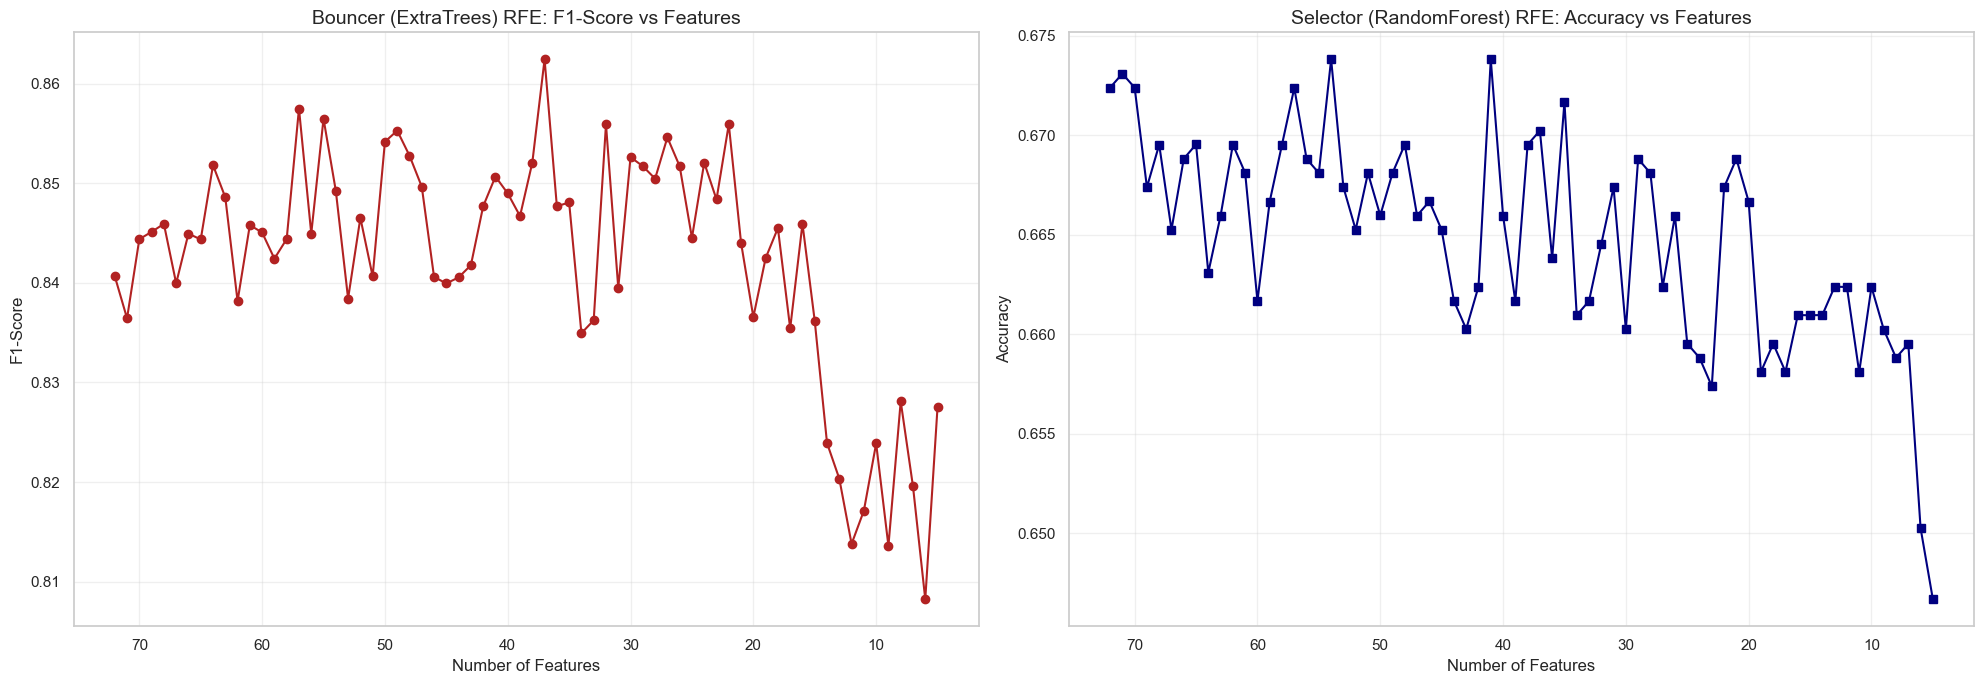


Bouncer Optimum: 37 features (F1: 0.8624)
Selector Optimum: 54 features (Acc: 0.6738)


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score

min_features_to_keep = 5
step = 1
valid_mask = df['best_solver'].notna()

def run_rfe_for_model(model_type='bouncer'):
    print(f"\n--- Starting RFE for {model_type.upper()} ---")
    
    current_features = list(feature_cols)
    results = []
    
    if model_type == 'bouncer':
        model = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        X_target = X_all_scaled
        y_target = y_hard
    else:
        model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        X_target = X_all_scaled[valid_mask]
        y_target = df['best_solver'].dropna()
        y_target = le.transform(y_target)

    while len(current_features) >= min_features_to_keep:
        current_indices = [feature_cols.index(f) for f in current_features]
        X_subset = X_target[:, current_indices]
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = []
        
        for train_idx, test_idx in skf.split(X_subset, y_target):
            X_train, X_test = X_subset[train_idx], X_subset[test_idx]
            y_train, y_test = y_target[train_idx], y_target[test_idx]
            
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            
            if model_type == 'bouncer':
                scores.append(f1_score(y_test, preds))
            else:
                scores.append(accuracy_score(y_test, preds))
        
        avg_score = np.mean(scores)
        results.append({'num_features': len(current_features), 'score': avg_score})
        
        if len(current_features) % 10 == 0:
            print(f"Features: {len(current_features)} | Score: {avg_score:.4f}")

        model.fit(X_subset, y_target)
        importances = pd.Series(model.feature_importances_, index=current_features)
        
        to_drop = importances.nsmallest(step).index.tolist()
        current_features = [f for f in current_features if f not in to_drop]
        
    return pd.DataFrame(results)

bouncer_rfe_df = run_rfe_for_model(model_type='bouncer')
selector_rfe_df = run_rfe_for_model(model_type='selector')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

ax1.plot(bouncer_rfe_df['num_features'], bouncer_rfe_df['score'], color='firebrick', marker='o')
ax1.set_title('Bouncer (ExtraTrees) RFE: F1-Score vs Features', fontsize=14)
ax1.set_xlabel('Number of Features')
ax1.set_ylabel('F1-Score')
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)

ax2.plot(selector_rfe_df['num_features'], selector_rfe_df['score'], color='navy', marker='s')
ax2.set_title('Selector (RandomForest) RFE: Accuracy vs Features', fontsize=14)
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Accuracy')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_b = bouncer_rfe_df.loc[bouncer_rfe_df['score'].idxmax()]
best_s = selector_rfe_df.loc[selector_rfe_df['score'].idxmax()]

print(f"\nBouncer Optimum: {int(best_b['num_features'])} features (F1: {best_b['score']:.4f})")
print(f"Selector Optimum: {int(best_s['num_features'])} features (Acc: {best_s['score']:.4f})")

## 16. Comparing Feature Bands
Different feature bands are tested to determine a point where the model still performs well, with reduced features

In [38]:
def evaluate_pipeline(df, X_scaled, y_hard, feature_indices, feature_cols):
    """Runs your custom 5-Fold CV and returns Exact Counts and PAR-2."""
    X_subset = X_scaled[:, feature_indices]
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_portfolio_par2, cv_portfolio_solved = 0, 0
    
    for train_idx, test_idx in skf.split(X_subset, y_hard):
        X_train_fold, X_test_fold = X_subset[train_idx], X_subset[test_idx]
        y_hard_train_fold = y_hard.iloc[train_idx]
        
        train_df_fold = df.iloc[train_idx]
        valid_selector_mask = train_df_fold['best_solver'].notna().values
        
        X_train_selector = X_train_fold[valid_selector_mask]
        y_train_selector = train_df_fold['best_solver'].dropna().values
        
        # Train Models
        rf_bouncer = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        rf_bouncer.fit(X_train_fold, y_hard_train_fold)
        
        rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        rf_selector.fit(X_train_selector, y_train_selector)
        
        test_actual_indices = df.iloc[test_idx].index 
        for i, idx in enumerate(test_actual_indices):
            true_solver = df.loc[idx, 'best_solver']
            true_sol = np.round(float(df.loc[idx, f'solutions_{true_solver}']), 5) if pd.notna(true_solver) else np.nan
            
            if rf_bouncer.predict(X_test_fold[i].reshape(1, -1))[0] == 1:
                cv_portfolio_par2 += TIMEOUT_LIMIT * 2
                continue
                
            pred_solver = rf_selector.predict(X_test_fold[i].reshape(1, -1))[0]
            p_time = df.loc[idx, f'time_{pred_solver}']
            p_sol = np.round(float(df.loc[idx, f'solutions_{pred_solver}']), 5)
            
            if pd.isna(p_time) or p_time >= TIMEOUT_LIMIT or pd.isna(true_sol) or p_sol != true_sol:
                cv_portfolio_par2 += TIMEOUT_LIMIT * 2
            else:
                cv_portfolio_par2 += p_time
                cv_portfolio_solved += 1
                
    return cv_portfolio_solved, cv_portfolio_par2




def get_top_n_features(model_type, n):
    """Re-runs a quick fit to get the Top N features for a specific stage."""
    if model_type == 'bouncer':
        m = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        X_t, y_t = X_all_scaled, y_hard
    else:
        m = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        X_t, y_t = X_all_scaled[valid_mask], le.transform(df['best_solver'].dropna())
    
    m.fit(X_t, y_t)
    return pd.Series(m.feature_importances_, index=feature_cols).nlargest(n).index.tolist()

bands = [30, 25, 20, 15, 10, 5]
band_results = []
feature_sets = {}

print("Starting Band Comparison...\n")

for n in bands:
    b_features = get_top_n_features('bouncer', n)
    s_features = get_top_n_features('selector', n)
    
    pipeline_features = list(set(b_features) | set(s_features))
    feature_sets[n] = {'bouncer': b_features, 'selector': s_features, 'union': pipeline_features}
    
    indices = [feature_cols.index(f) for f in pipeline_features]
    X_sliced = X_all_scaled[:, indices]
    
    solved, par2 = evaluate_pipeline(df, X_all_scaled, y_hard, indices, feature_cols)
    
    band_results.append({
        "Band": n,
        "Total Pipeline Features": len(pipeline_features),
        "Exact Counts": solved,
        "PAR-2 Score": par2
    })
    print(f"Band {n}: {len(pipeline_features)} unique features | Counts: {solved} | PAR-2: {par2:,.0f}")

comparison_df = pd.DataFrame(band_results)
display(comparison_df)

Starting Band Comparison...

Band 30: 48 unique features | Counts: 1385 | PAR-2: 6,395,077
Band 25: 41 unique features | Counts: 1387 | PAR-2: 6,375,231
Band 20: 34 unique features | Counts: 1388 | PAR-2: 6,364,989
Band 15: 25 unique features | Counts: 1388 | PAR-2: 6,362,180
Band 10: 18 unique features | Counts: 1387 | PAR-2: 6,372,713
Band 5: 9 unique features | Counts: 1384 | PAR-2: 6,398,681


,Band,Total Pipeline Features,Exact Counts,PAR-2 Score
0,30,48,1385,6.395077e+06
1,25,41,1387,6.375231e+06
2,20,34,1388,6.364989e+06
3,15,25,1388,6.362180e+06
4,10,18,1387,6.372713e+06
5,5,9,1384,6.398681e+06


## 17. Evaluation
Comparing final models against SBS and Orcale

In [39]:
final_bouncer_features = get_top_n_features('bouncer', 15)
final_selector_features = get_top_n_features('selector', 15)
final_union_features = list(set(final_bouncer_features) | set(final_selector_features))

final_indices = [feature_cols.index(f) for f in final_union_features]
X_final = X_all_scaled[:, final_indices]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stats = {
    'oracle': {'par2': 0, 'solved': 0},
    'sbs': {'par2': 0, 'solved': 0},
    'portfolio': {'par2': 0, 'solved': 0, 'time_saved': 0}
}

print(f"Executing Final Validation with {len(final_union_features)} Optimized Features...")
print(f"Bouncer: ExtraTrees | Selector: RandomForest\n")

for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y_hard)):
    X_train_f, X_test_f = X_final[train_idx], X_final[test_idx]
    y_h_train = y_hard.iloc[train_idx]
    
    train_df = df.iloc[train_idx]
    sel_mask = train_df['best_solver'].notna().values
    X_train_sel = X_train_f[sel_mask]
    y_train_sel = train_df['best_solver'].dropna().values
    
    bouncer = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    bouncer.fit(X_train_f, y_h_train)
    
    selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    selector.fit(X_train_sel, y_train_sel)
    
    test_indices = df.iloc[test_idx].index
    for i, idx in enumerate(test_indices):
        true_solver = df.loc[idx, 'best_solver']
        true_sol = np.round(float(df.loc[idx, f'solutions_{true_solver}']), 2) if pd.notna(true_solver) else np.nan
        
        if pd.isna(true_sol):
            stats['oracle']['par2'] += TIMEOUT_LIMIT * 2
        else:
            stats['oracle']['par2'] += df.loc[idx, f'time_{true_solver}']
            stats['oracle']['solved'] += 1
            
        sbs_time = df.loc[idx, 'time_gpmc']
        sbs_sol = np.round(float(df.loc[idx, 'solutions_gpmc']), 2)
        if pd.isna(sbs_time) or sbs_time >= TIMEOUT_LIMIT or pd.isna(true_sol) or sbs_sol != true_sol:
            stats['sbs']['par2'] += TIMEOUT_LIMIT * 2
        else:
            stats['sbs']['par2'] += sbs_time
            stats['sbs']['solved'] += 1

        if bouncer.predict(X_test_f[i].reshape(1, -1))[0] == 1:
            stats['portfolio']['par2'] += TIMEOUT_LIMIT * 2
            if df.loc[idx, 'is_hard'] == 1:
                stats['portfolio']['time_saved'] += TIMEOUT_LIMIT
        else:
            p_solver = selector.predict(X_test_f[i].reshape(1, -1))[0]
            p_time = df.loc[idx, f'time_{p_solver}']
            p_sol = np.round(float(df.loc[idx, f'solutions_{p_solver}']), 2)
            
            if pd.isna(p_time) or p_time >= TIMEOUT_LIMIT or pd.isna(true_sol) or p_sol != true_sol:
                stats['portfolio']['par2'] += TIMEOUT_LIMIT * 2
            else:
                stats['portfolio']['par2'] += p_time
                stats['portfolio']['solved'] += 1


print("==================================================")
print("       FINAL SYSTEM PERFORMANCE ANALYTICS         ")
print("==================================================")
print(f"Feature Set: Reduced to {len(final_union_features)} keys (Band 30 Optimization)")
print(f"Total Compute Time Avoided: {stats['portfolio']['time_saved']:,.0f} seconds")
print("-" * 50)

results_table = pd.DataFrame({
    "Metric": ["Exact Counts", "PAR-2 Score", "Gap to Oracle"],
    "Oracle (VBS)": [f"{stats['oracle']['solved']}/2023", f"{stats['oracle']['par2']:,.2f}", "0.00"],
    "SBS (GPMC)": [f"{stats['sbs']['solved']}/2023", f"{stats['sbs']['par2']:,.2f}", f"{stats['sbs']['par2'] - stats['oracle']['par2']:,.2f}"],
    "ML Portfolio": [f"{stats['portfolio']['solved']}/2023", f"{stats['portfolio']['par2']:,.2f}", f"{stats['portfolio']['par2'] - stats['oracle']['par2']:,.2f}"]
})

display(results_table)

Executing Final Validation with 25 Optimized Features...
Bouncer: ExtraTrees | Selector: RandomForest

       FINAL SYSTEM PERFORMANCE ANALYTICS         
Feature Set: Reduced to 25 keys (Band 30 Optimization)
Total Compute Time Avoided: 550,000 seconds
--------------------------------------------------


,Metric,Oracle (VBS),SBS (GPMC),ML Portfolio
0,Exact Counts,1401/2023,1378/2023,1389/2023
1,PAR-2 Score,"6,222,786.52","6,462,886.69","6,352,180.26"
2,Gap to Oracle,0.00,"240,100.17","129,393.74"


In [41]:
sbs_par2 = stats['sbs']['par2']
portfolio_par2 = stats['portfolio']['par2']
oracle_par2 = stats['oracle']['par2']

total_possible_improvement = sbs_par2 - oracle_par2

gap_closed = sbs_par2 - portfolio_par2
pct_gap_closed = (gap_closed / total_possible_improvement) * 100

avg_sbs_time = stats['sbs']['par2'] / total_instances
avg_portfolio_time = stats['portfolio']['par2'] / total_instances
speedup = avg_sbs_time / avg_portfolio_time

portfolio_total_time = stats['portfolio']['par2'] / 2

sbs_waste = (total_instances - stats['sbs']['solved']) * TIMEOUT_LIMIT
portfolio_waste = (total_instances - stats['portfolio']['solved']) * TIMEOUT_LIMIT

actual_clock_saved = stats['portfolio']['time_saved']


print("==================================================")
print("           IMPACT ANALYSIS          ")
print("==================================================")
print(f"Percentage of Potential Realized: {pct_gap_closed:.2f}%")
print(f"Portfolio Speedup Factor vs SBS:  {speedup:.2f}x faster")
print(f"Reliability Gain:                 +{stats['portfolio']['solved'] - stats['sbs']['solved']} more instances solved")
print(f"Total Wall-Clock Time Saved:   {actual_clock_saved:,.0f} seconds")
print(f"Equivalent Work Days Saved:    {actual_clock_saved / 86400:.2f} days of CPU time")

           IMPACT ANALYSIS          
Percentage of Potential Realized: 46.11%
Portfolio Speedup Factor vs SBS:  1.02x faster
Reliability Gain:                 +11 more instances solved
Total Wall-Clock Time Saved:   550,000 seconds
Equivalent Work Days Saved:    6.37 days of CPU time
